Sergio Alejandro Holguin García

Analitica de Datos

Taller

La base de datos "Online Retail II" contiene datos transaccionales de una tienda minorista en línea no especificada del Reino Unido entre el periodo 2009-2010.

Esta base de datos contiene los siguientes datos:


1.   **InvoiceNo**: Representa el número de factura de cada transacción. Este es un código alfanumérico que típicamente comienza con una letra seguida por números. Los códigos que comienzan con 'C' indican cancelaciones.

2.   **StockCode**: Código de producto utilizado internamente por la tienda para identificar cada artículo. Este código es también alfanumérico y permite diferenciar los productos entre sí.

3. **Description**: Descripción textual del producto. Este campo detalla lo que se está vendiendo en cada transacción y es útil para identificar los ítems sin necesidad de referirse al StockCode.

4. **Quantity**: La cantidad de cada producto comprado en cada transacción. Los números negativos pueden indicar devoluciones o cancelaciones.

5. **InvoiceDate**: La fecha y hora exacta cuando se realizó la transacción. Este campo es crucial para análisis que requieren entender patrones de compra a lo largo del tiempo, como la estacionalidad y las tendencias.


6. **UnitPrice**: El precio por unidad de cada producto, expresado en libras esterlinas. Este campo es esencial para calcular los ingresos generados por cada venta.

7. **CustomerID**: Un código numérico único asignado a cada cliente. Este identificador es importante para realizar análisis de segmentación de clientes y para entender el comportamiento de compra de clientes individuales.

8. **Country**: El país de residencia del cliente. Esto permite análisis geográficos de las ventas y puede ayudar a comprender la distribución global de los clientes y la popularidad de productos en diferentes regiones.



















## Librerias y lectura

In [2]:
import pandas as pd #dataframes
import seaborn as sns #visualizaciones
import matplotlib.pyplot as plt
import numpy as np #arreglos numericos

# Cargamos nuestra base de datos, como son 2 hojas las concatenamos y visualizamos sus estádisticas.

In [ ]:
df1=pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")

In [ ]:
df2=pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [ ]:
df = pd.concat([df1, df2])

In [ ]:
data=pd.DataFrame(df)


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


# Limpieza y preprocesamiento

In [ ]:
#Visualizamos valores atipicos

for i in range(len(df.columns)):
    if df[df.columns[i]].dtype == "int64" or df[df.columns[i]].dtype == "float64":
        Q1 = df[df.columns[i]].quantile(0.25)
        Q3 = df[df.columns[i]].quantile(0.75)
        IQR = Q3 - Q1
        umbral_superior = Q3 + 1.5 * IQR
        umbral_inferior = Q1 - 1.5 * IQR
        valores_atipicos = df[(df[df.columns[i]] > umbral_superior) | (df[df.columns[i]] < umbral_inferior)]
        print("La variable:", df.columns[i], "tiene", len(valores_atipicos), "valores atípicos.")

La variable: Quantity tiene 116489 valores atípicos.
La variable: Price tiene 68105 valores atípicos.
La variable: Customer ID tiene 0 valores atípicos.


In [ ]:
#La columna de descripción no nos aporta nada, entonces la eliminamos
df_Nuevo = data.drop(columns=["Description"])

#realizamos una limpieza general de la base de datos donde eliminamos valores nulos y duplicados que pueden solo aportarle ruido a nuestro modelado
df_Nuevo = df_Nuevo.drop_duplicates()
df_Nuevo = df_Nuevo.dropna()

#Aplicamos nuestras reglas
df_Nuevo = df_Nuevo[df_Nuevo["Price"] >= 0] #No existen precios negativos
df_Nuevo = df_Nuevo[df_Nuevo["Quantity"] >= 0] #No existen cantidades negaticas
df_Nuevo.loc[:, 'Customer ID'] = df_Nuevo['Customer ID'].apply(str) #Convertimos los usuarios en objetos para que nuestro modelo lo interprete como datos unicos y uno una linea continúa
#Creamos una nueva columna
df_Nuevo['Ventas'] = df_Nuevo['Quantity'] * df_Nuevo['Price']
df_Nuevo

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Ventas
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541908,581587,22138,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


# Visualizacion

Despues de realizar todo el preprocesamiento de la base de datos es importante entender que es lo que quiere el cliente para saber que vamos a mostrar. En este ejemplo vamos a realizar graficas en relación con el numero de ventas por pais, por cliente, por fecha y cantidad por productos

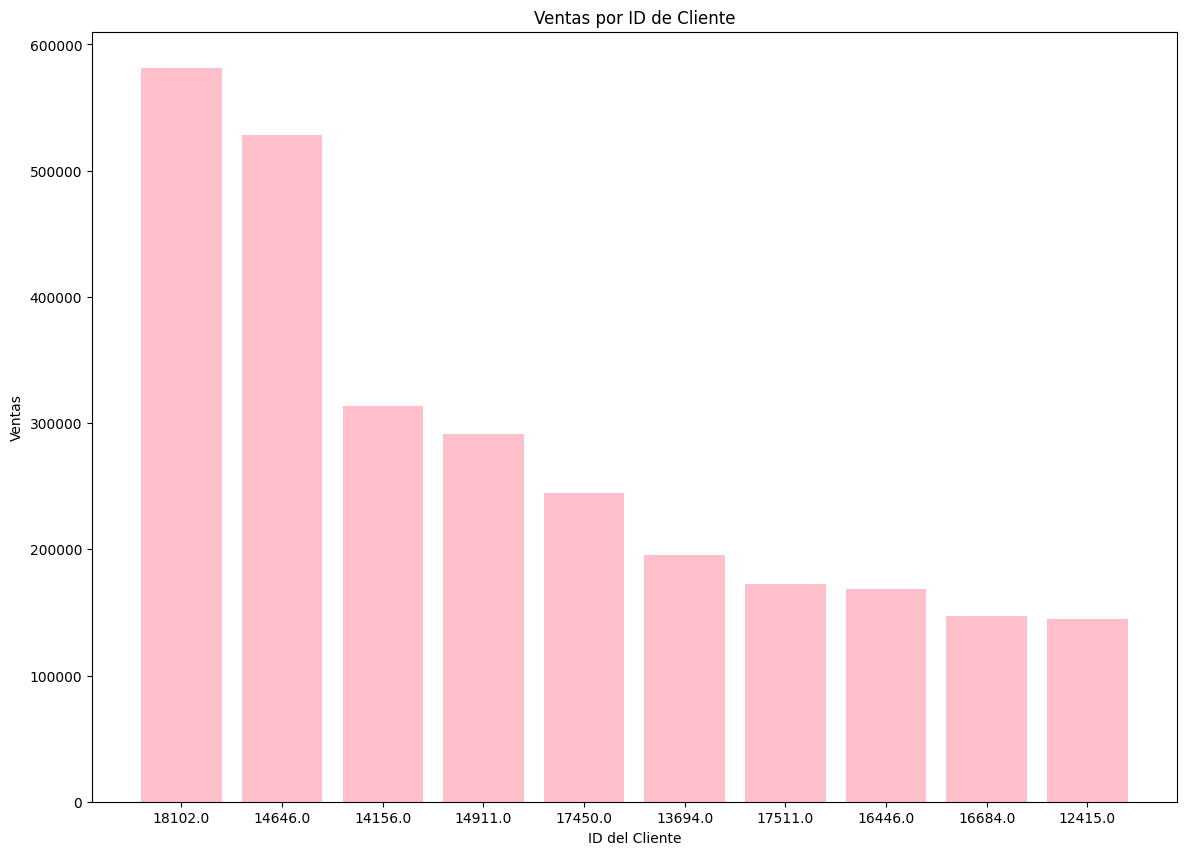

In [ ]:
import seaborn as sns
#Convertimos nuestro dataframe en numerico para que se pueda ordenar
df_numerico = df_Nuevo.select_dtypes(include=[np.number])
dfnuevo = df_numerico.groupby(by=df_Nuevo["Customer ID"]).sum()
# Ordenar Customer ID según Ventas  de forma descendente
dfnuevo = dfnuevo.sort_values(by = 'Ventas', ascending = False)

#Gráfica - Ventas por Customer ID
plt.figure(figsize=(14, 10))
plt.bar(x = dfnuevo.index[:10], height = dfnuevo["Ventas"].head(10), color='pink')
plt.xlabel('ID del Cliente')
plt.ylabel('Ventas')
plt.title('Ventas por ID de Cliente')
plt.show()


La grafica anterior nos muestra ordenadamente los 10 clientes que más ha comprado en la plataforma teniendo en cuenta que el cliente 18102.0 ha gastado al rededor de 600.000 libras esterlinas. Esto puede ayudar principalmente a la empresa para tener prioridad en la venta a ese cliente ya que es frecuente y además realiza compra de motos muy grandes.

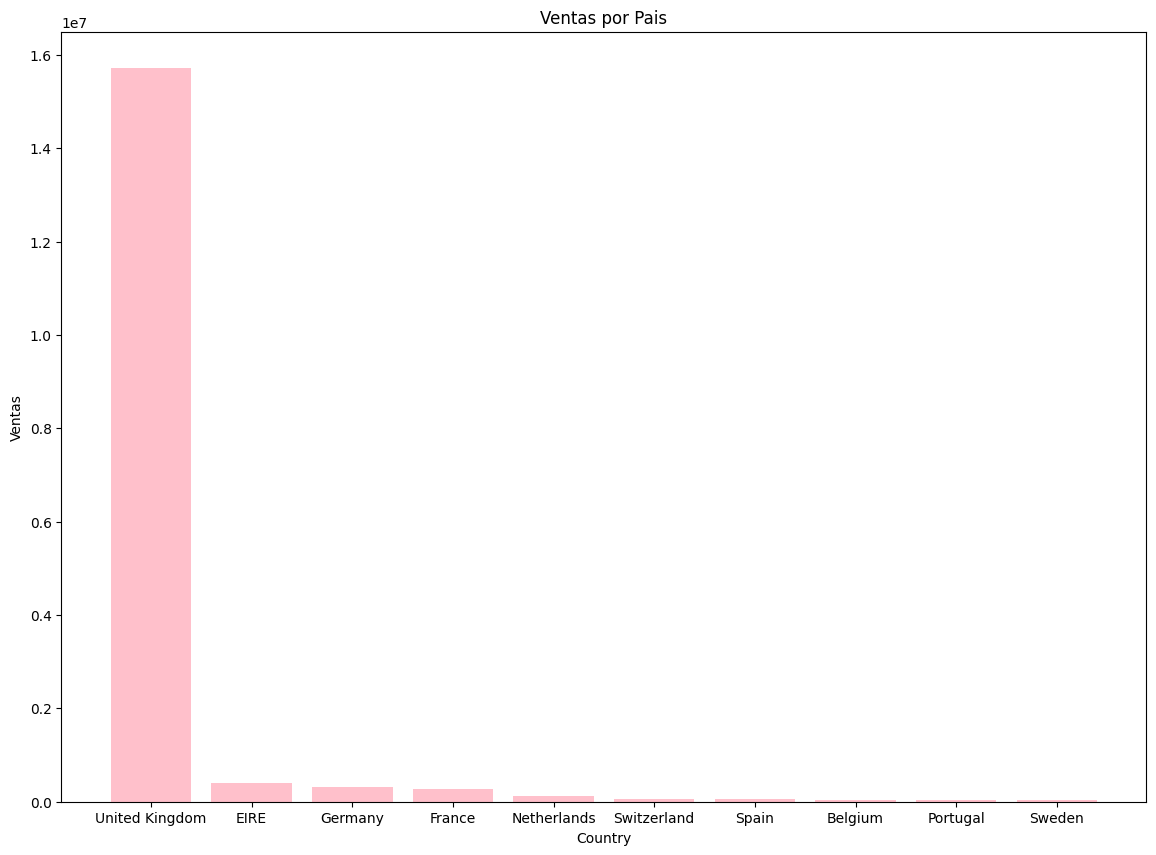

In [ ]:
#Seleccionar las columnas numéricas
df_num = df_Nuevo.select_dtypes(include=[np.number])
#Agrupar por paises, para obtener las ventas totales por cada país
df_Nuevo = df_Nuevo.reset_index(drop=True)
df_paises = df_num.groupby(by = df_Nuevo['Country']).sum()
#Orden países según ventas, de forma descendente
df_paises = df_paises.sort_values(by = 'Ventas', ascending = False)

#Gráfica - Ventas por Country
plt.figure(figsize=(14, 10))
plt.bar(x = df_paises.index[:10], height = df_paises["Ventas"].head(10), color='pink')
plt.xlabel('Country')
plt.ylabel('Ventas')
plt.title('Ventas por Pais')
plt.show()

La grafica anterior nos muestra cual es el pais que más compra, tiene sentido teniendo en cuenta que la base de datos es de reino unido, sin embargo no nos aporta más información.

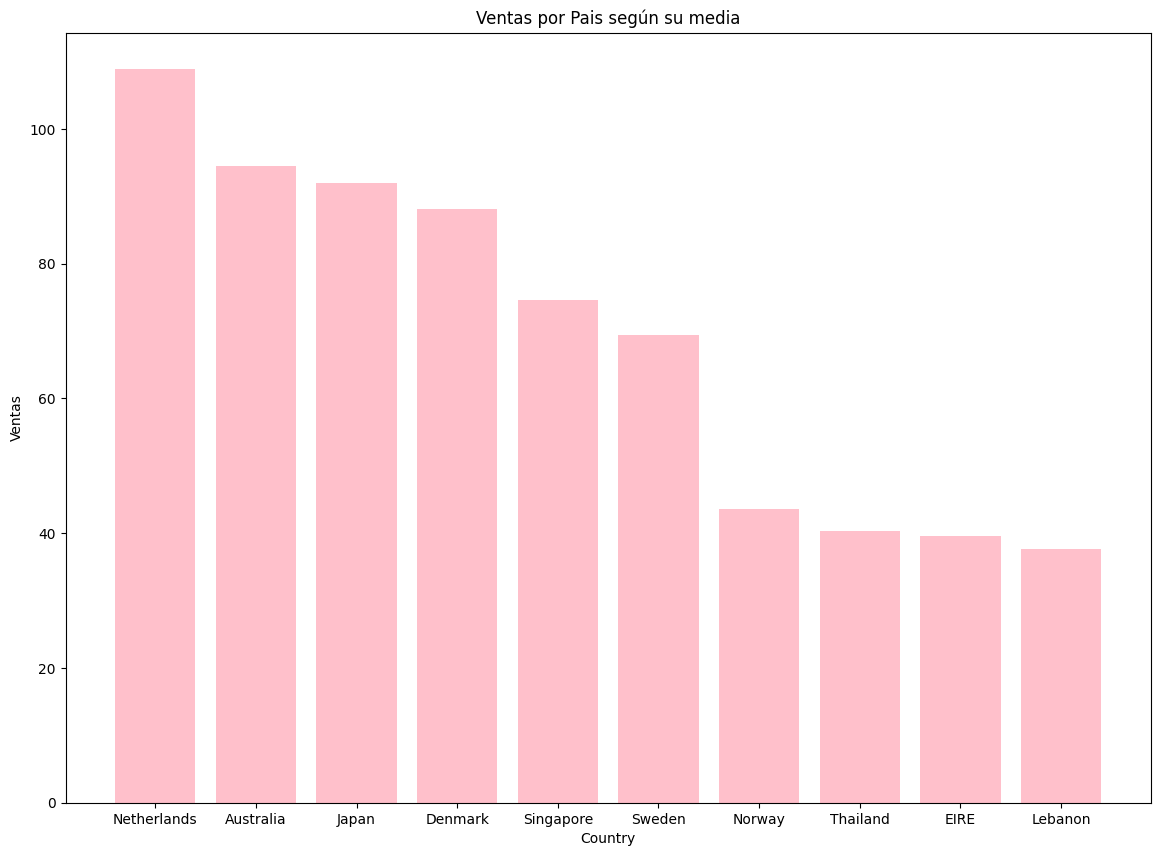

In [ ]:
#Seleccionar las columnas numéricas
df_num = df_Nuevo.select_dtypes(include=[np.number])
#Agrupar por paises, para obtener las ventas totales por cada país
df_Nuevo = df_Nuevo.reset_index(drop=True)
df_paises = df_num.groupby(by = df_Nuevo['Country']).mean()
#Orden países según ventas, de forma descendente
df_paises = df_paises.sort_values(by = 'Ventas', ascending = False)

#Gráfica - Ventas por Country
plt.figure(figsize=(14, 10))
plt.bar(x = df_paises.index[:10], height = df_paises["Ventas"].head(10), color='pink')
plt.xlabel('Country')
plt.ylabel('Ventas')
plt.title('Ventas por Pais según su media')
plt.show()

Por esto, como se muestra en la figura anterior en este caso es mejor mostrar la media de los paises que más compran donde los datos se distribuyen de mejor maneras e ironicamente aunque reinio unido sea que pais que más compra en promedio no entra en la lista de los paises que más compran. En este caso paises bajos muestra mejor relación, lo que puede signficar para el empresario que se puede ofrecer más publicidad en esa zona ya que son clientes potenciales.

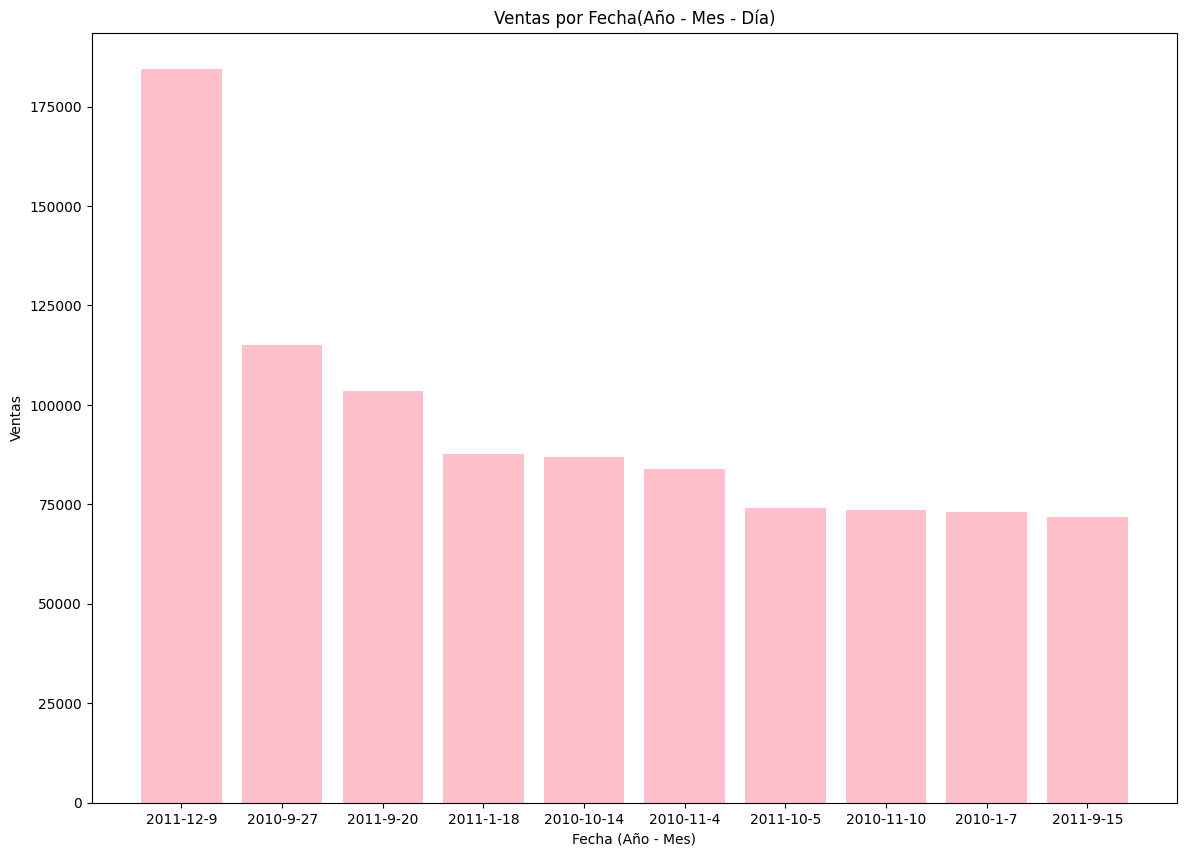

In [ ]:
#Separar año, mes y día de Invoice Date
data_meses = df_Nuevo
data_meses['Año'] = pd.to_datetime(data_meses['InvoiceDate']).dt.year
data_meses['Mes'] = pd.to_datetime(data_meses['InvoiceDate']).dt.month
data_meses['Dia'] = pd.to_datetime(data_meses['InvoiceDate']).dt.day

#Convertir enteros a string
data_meses['Dia'] = data_meses['Dia'].astype(str)
data_meses['Mes'] = data_meses['Mes'].astype(str)
data_meses['Año'] = data_meses['Año'].astype(str)

#Crear nuevas columnas con el formato año-mes-día y año_mes, para poder agrupar las ventas
data_meses ['Año_Mes_Dia'] = data_meses['Año'] + '-' + data_meses['Mes'] + '-' + data_meses['Dia']
data_meses ['Año_Mes'] = data_meses['Año'] + '-' + data_meses['Mes']

#Agrupar por año-mes-día, para obtener las ventas totales por cada fecha
data_num_mes = df_Nuevo.select_dtypes(include=[np.number])
data_amd = data_num_mes.groupby(by=data_meses['Año_Mes_Dia']).sum()

#Organizar fecha según ventas, de forma descendente
data_amd = data_amd.sort_values(by = 'Ventas', ascending = False)

#Graficar - Ventas por Fecha
plt.figure(figsize=(14, 10))
plt.bar(x = data_amd.index[:10], height = data_amd["Ventas"].head(10), color='pink')
plt.xlabel('Fecha (Año - Mes)')
plt.ylabel('Ventas')
plt.title('Ventas por Fecha(Año - Mes - Día)')
plt.show()

Para el empresario también es fundamental que día vendió más para aumentar la logistica esos días, el sabado 12 de noviembre de 2011 fue el día que más se vendió, este dato le puede servir al empresario para proyectar el personal para las siguientes fechas

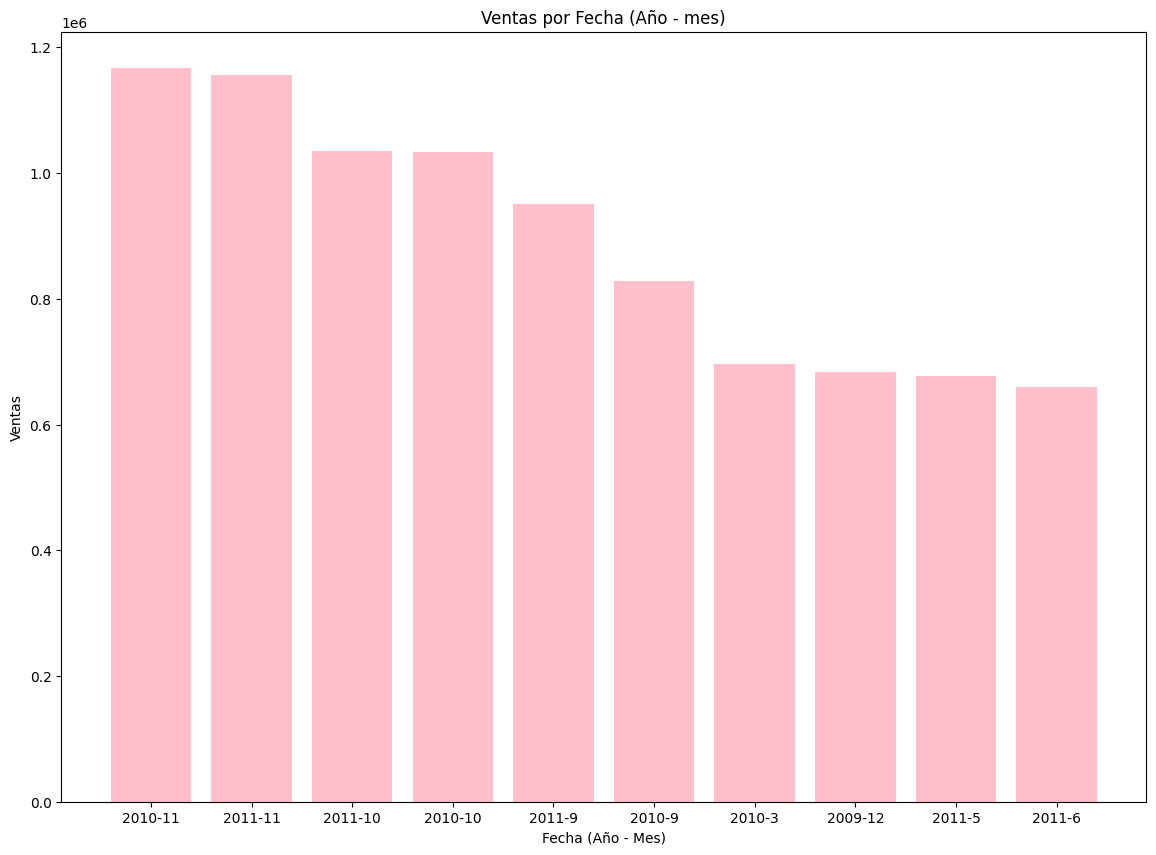

In [ ]:
#Agrupar por año-mes, para obtener las ventas totales por cada fecha, excluyendo el día
data_am = data_num_mes.groupby(by=data_meses['Año_Mes']).sum()

#Organizar fecha según ventas, de forma descendente
data_am = data_am.sort_values(by = 'Ventas', ascending = False)

#Graficar - Ventas por Fecha
plt.figure(figsize=(14, 10))
plt.bar(x = data_am.index[:10], height = data_am["Ventas"].head(10), color='pink')
plt.xlabel('Fecha (Año - Mes)')
plt.ylabel('Ventas')
plt.title('Ventas por Fecha (Año - mes)')
plt.show()


Además del día, es importante saber el mes, donde vemos que claramente noviembre es el mes que más se vende, posiblemente por la cercania a las festividades navideñas y por los dias fuertes de promociones.

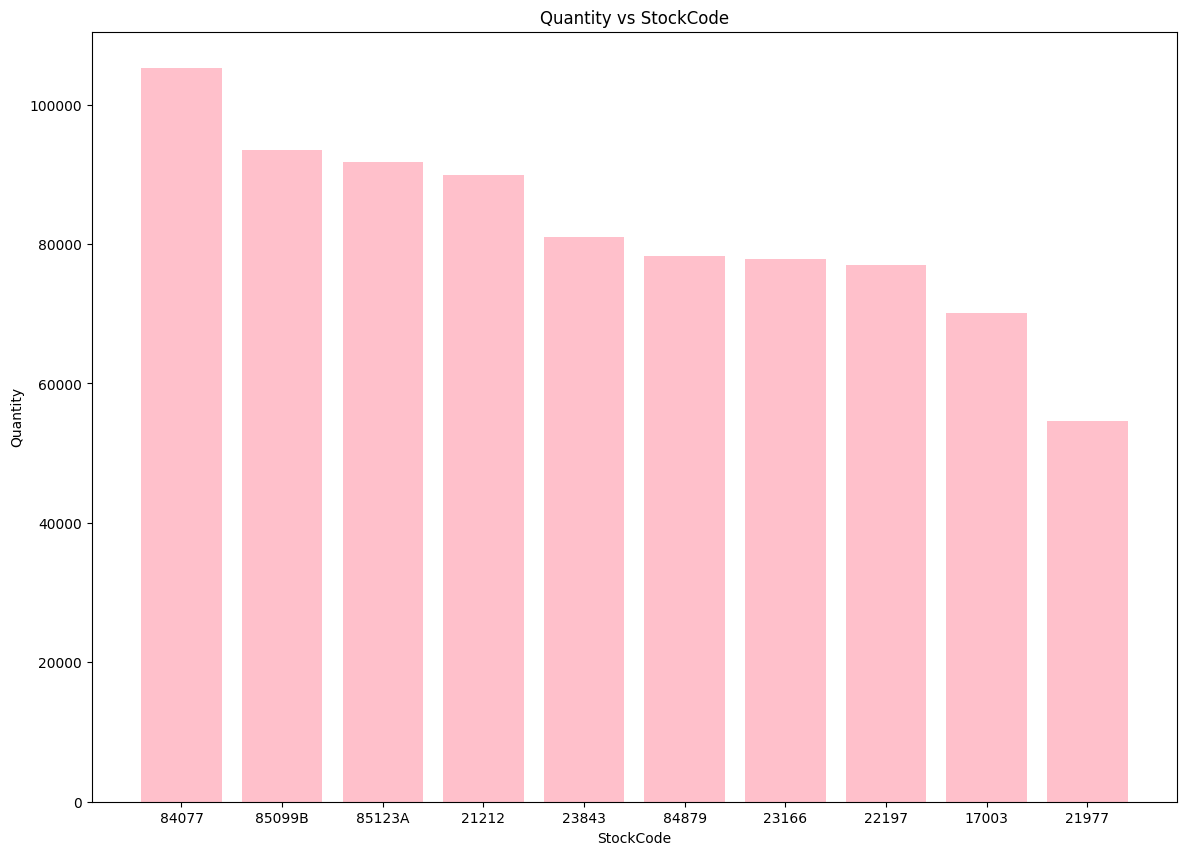

In [ ]:

#Dataset para stockcode vs Quantity
data_quantity = df_num.groupby(by = df_Nuevo['StockCode']).sum()
#Organizar StockCode según quantity
data_quantity = data_quantity.sort_values(by = 'Quantity', ascending = False)

#Graficar - StockCode vs Quantity
plt.figure(figsize=(14, 10))
plt.bar(x = data_quantity.index[:10].astype(str), height = data_quantity["Quantity"].head(10), color='pink')
plt.xlabel('StockCode')
plt.ylabel('Quantity')
plt.title('Quantity vs StockCode')
plt.show()

Finalmente tenemos la grafica del producto más vendido, lo que puede ser para el empresario el producto insigna y tambien podriamos observar el producto menos vendido, con este dato el empresario peude potenciar la publicidad de ese producto o directamtente dejar de venderlo para que no genere perdidas